# Violent Crime Rate in the State of California
*Gússem Yahia-Cheikh, María Colomer and Sara Díez*

## 1. Data loading and initial overview

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Firstly we loaded the original database which we obtained from [Data.gov](https://catalog.data.gov/dataset/violent-crime-rate-9a68e), bare in mind that we will modify the dataset so this isn't the dataframe we will use for all the project, just checking everything is fine.

In [25]:
df_original=pd.read_csv("VCC_updated.csv", encoding="ISO-8859-1")

In [ ]:
df_original  # Preview of the database to check that everything is correct

,reportyear,geoname,geotypevalue,county_name,county_fips,region_name,region_code,dof_population,AA,FR,M_and_NNM,R,VCT,rate
0,2000,Adelanto city,296,San Bernardino,6071,Southern California,14,18130,0.005461,0.000221,0.000110,0.000772,0.006564,6.563707
1,2000,Agoura Hills city,394,Los Angeles,6037,Southern California,14,20537,0.001169,0.000097,0.000000,0.000487,0.001753,1.752934
2,2000,Alameda,6001,Alameda,6001,Bay Area,1,1443939,0.003780,0.000393,0.000076,0.002333,0.006582,6.582206
3,2000,Alameda city,562,Alameda,6001,Bay Area,1,72259,0.002519,0.000125,0.000014,0.001522,0.004179,4.179410
4,2000,Albany city,674,Alameda,6001,Bay Area,1,16444,0.002858,0.000182,0.000000,0.002311,0.005351,5.351496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7122,2013,Tehachapi city,78092,Kern,6029,San Joaquin Valley,10,13316,0.002131,0.000367,0.000000,0.000514,0.003013,3.013155
7123,2013,Wildomar city,85446,Riverside,6065,Southern California,14,33416,0.000807,0.000060,0.000000,0.000329,0.001196,1.195707
7124,2013,Angels city,2112,Calaveras,6009,Central/Southeast Sierra,3,3806,0.001877,0.000268,0.000000,0.000268,0.002414,2.413516
7125,2013,McFarland city,44826,Kern,6029,San Joaquin Valley,10,13141,0.003581,0.000163,0.000081,0.001465,0.005290,5.289714


In [ ]:
df_original.info()
df_original.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7127 entries, 0 to 7126
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reportyear      7127 non-null   int64  
 1   geoname         7127 non-null   object 
 2   geotypevalue    7127 non-null   int64  
 3   county_name     7127 non-null   object 
 4   county_fips     7127 non-null   int64  
 5   region_name     7127 non-null   object 
 6   region_code     7127 non-null   int64  
 7   dof_population  7127 non-null   int64  
 8   AA              7127 non-null   float64
 9   FR              7127 non-null   float64
 10  M_and_NNM       7127 non-null   float64
 11  R               7127 non-null   float64
 12  VCT             7127 non-null   float64
 13  rate            7127 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 779.6+ KB


,reportyear,geotypevalue,county_fips,region_code,dof_population,AA,FR,M_and_NNM,R,VCT,rate
count,7127.000000,7127.000000,7127.000000,7127.000000,7.127000e+03,7127.000000,7127.000000,7127.000000,7127.000000,7127.000000,7127.000000
mean,2006.514803,38714.311211,6056.138207,8.699453,1.293459e+05,0.003192,0.000279,0.000054,0.001882,0.005407,5.406838
std,4.027136,26461.629975,29.494075,5.145514,5.376305e+05,0.009658,0.000751,0.000495,0.015816,0.025788,25.788374
min,2000.000000,296.000000,6001.000000,1.000000,9.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003.000000,13112.000000,6037.000000,4.000000,1.304950e+04,0.001190,0.000109,0.000000,0.000355,0.001965,1.965312
50%,2007.000000,39122.000000,6059.000000,10.000000,3.492800e+04,0.002180,0.000205,0.000016,0.000756,0.003437,3.436840
75%,2010.000000,60620.000000,6079.000000,14.000000,7.962250e+04,0.003567,0.000324,0.000053,0.001437,0.005396,5.396215
max,2013.000000,87056.000000,6115.000000,14.000000,1.001764e+07,0.319149,0.032258,0.022222,0.489362,0.795699,795.698925


## 2. Geographic Visualization

To achieve creating the 2D geographic plot of the state of California we've divided the work as:
1. Create a csv with all the coordinates for each city in California
   
2. Merge it to the original database
   
3. Check if any error or malfunction in the process
   
4. Plotting

### Step 1: Creating the csv with all coordinates
For this, we will be using the library geopy leveraging the [Nominatim API](https://nominatim.org/release-docs/latest/) from OpenStreetMap to geocode the `geoname` values automatically.

*For further information check [this article](https://www.kaggle.com/code/rayhanlahdji/geocoding-with-geopy-nominatim) where we've learnet about how to use it and why*

In [33]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [ ]:
# Get unique city or region names (non-null values) from the 'geoname' column
cities = df_original["geoname"].dropna().unique()

# Set up the Nominatim geolocator (with user agent to respect usage policy)
geolocator = Nominatim(user_agent="geo_plot_app")

# Apply a rate limiter to avoid being blocked for sending requests too quickly
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Initialize a list to store tuples of (city_name, latitude, longitude)
city_coords = []

# Loop through each city name and retrieve its coordinates from Nominatim
for city in cities:
    loc = geocode(f"{city}, California, USA")  # Add region/country for better accuracy
    if loc:
        city_coords.append((city, loc.latitude, loc.longitude))
    else:
        # If the city is not found, store None for coordinates
        city_coords.append((city, None, None))

# Create a DataFrame from the collected coordinate data
coord_df = pd.DataFrame(city_coords, columns=["geoname", "lat", "lon"])

# Save the coordinates to a CSV for merging and future reuse (avoids repeating API calls)
coord_df.to_csv("city_coords.csv", index=False)

In [ ]:
df_coords = pd.read_csv("city_coords.csv") #Loading the coordinates database

### Step 2: Merging it to the original database

In [ ]:
df_original[['geoname']].drop_duplicates().head()
df_coords[['geoname']].drop_duplicates().head() #Here we ensure that both dataframes use the same keys, geoname

,geoname
0,Adelanto city
1,Agoura Hills city
2,Alameda
3,Alameda city
4,Albany city


In [ ]:
df_merged = pd.merge(df_original, df_coords, on="geoname", how="left")

In [ ]:
df_merged.to_csv("VCC_with_coords.csv", index=False)

### Step 3: Check if theres any error or NaN in the merged dataframe
The output cell you will see it will have all values 0 since at the begining we had 20-30 missing values, since it was a small inconvinience we've searched its coordinates manually and added them into the merged database.

In [ ]:
print(df_merged[['geoname', 'lat', 'lon']].isnull().sum())

geoname    0
lat        0
lon        0
dtype: int64


In [ ]:
df_geo=pd.read_csv("VCC_with_coords.csv") 

### Step 4: Plotting

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
import numpy as np

In [ ]:
crime_categories = ["AA", "FR", "M_and_NNM", "R"]
crime_colors = {"AA": "red", "FR": "blue", "M_and_NNM": "green", "R": "purple"}

# Load background image of California
bg_img = mpimg.imread("California_Map2.png")

def plot_crime_clusters(year):
    filtered = df_geo[df_geo["reportyear"] == year]

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(bg_img, extent=[-124.45, -114.40, 32.40, 42.15], aspect='equal')

    # Plot each crime category
    for crime in crime_categories:
        subset = filtered[filtered[crime] > 0]
        ax.scatter(
            subset["lon"],
            subset["lat"],
            s=np.sqrt(subset[crime]) * 2000,  # Adjust scale as needed
            c=crime_colors[crime],
            alpha=0.5,
            label=crime
        )

    # Set map limits and labels
    ax.set_xlim(-125, -113)
    ax.set_ylim(32, 43)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"California Violent Crime Clusters by Type ({year})", fontsize=13)

    # Create cleaner legend with just color markers
    handles = [Line2D([0], [0], marker='o', color='w', label=label,
                      markerfacecolor=color, markersize=10)
               for label, color in crime_colors.items()]
    ax.legend(handles=handles, title="Crime Type")

    
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

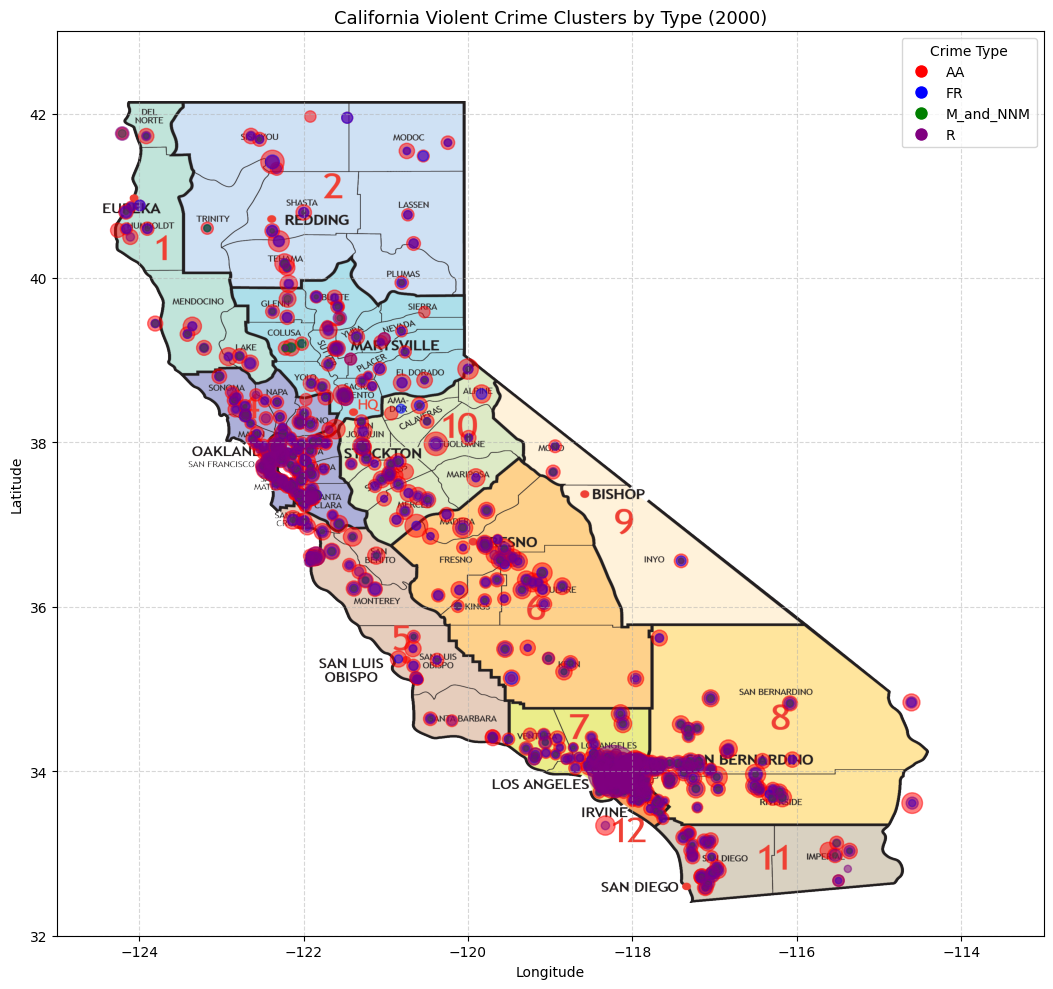

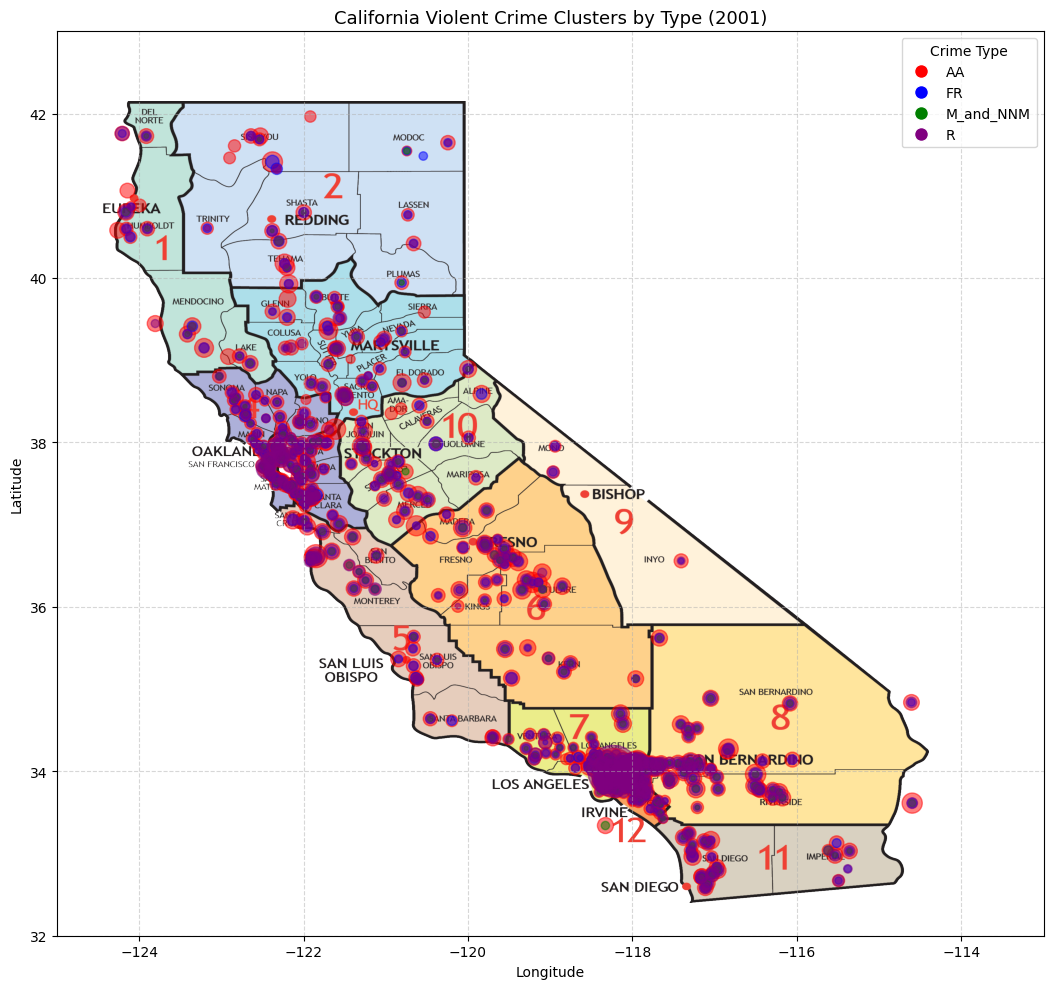

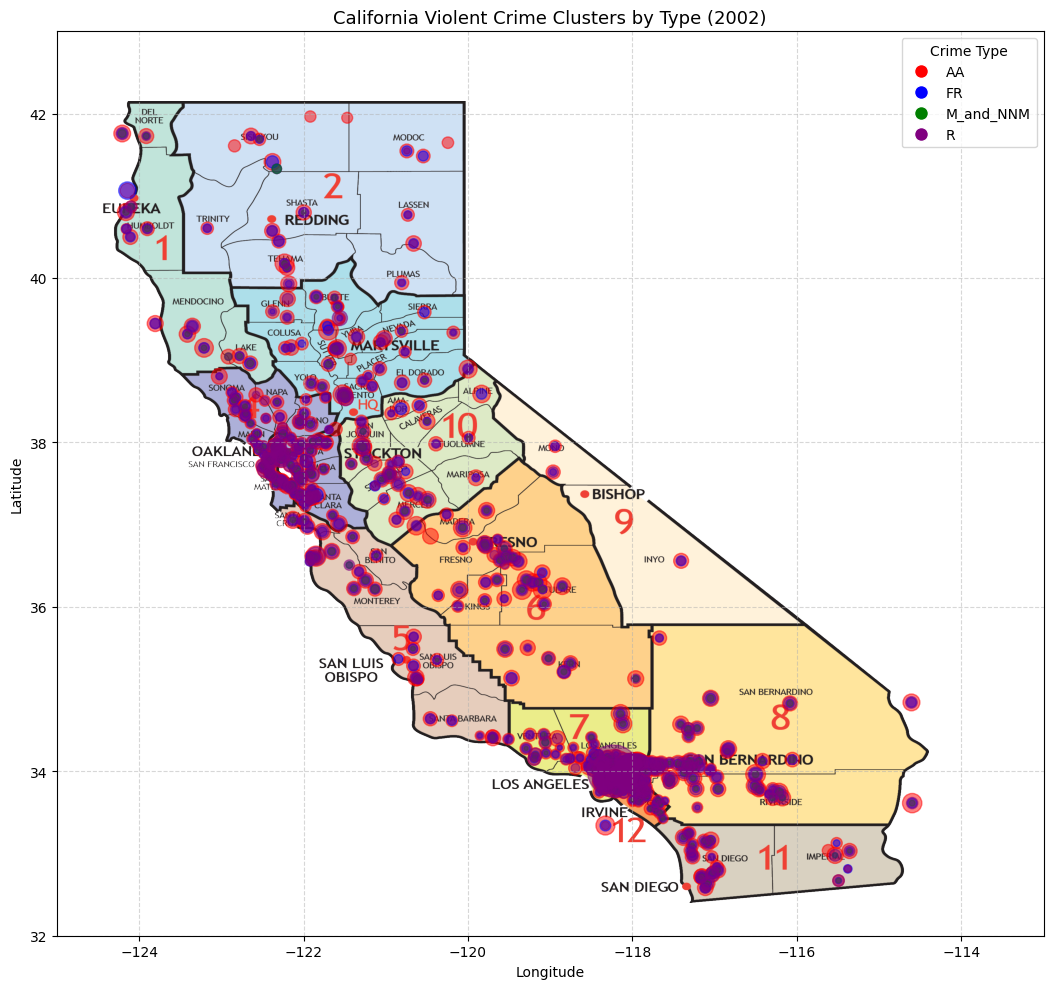

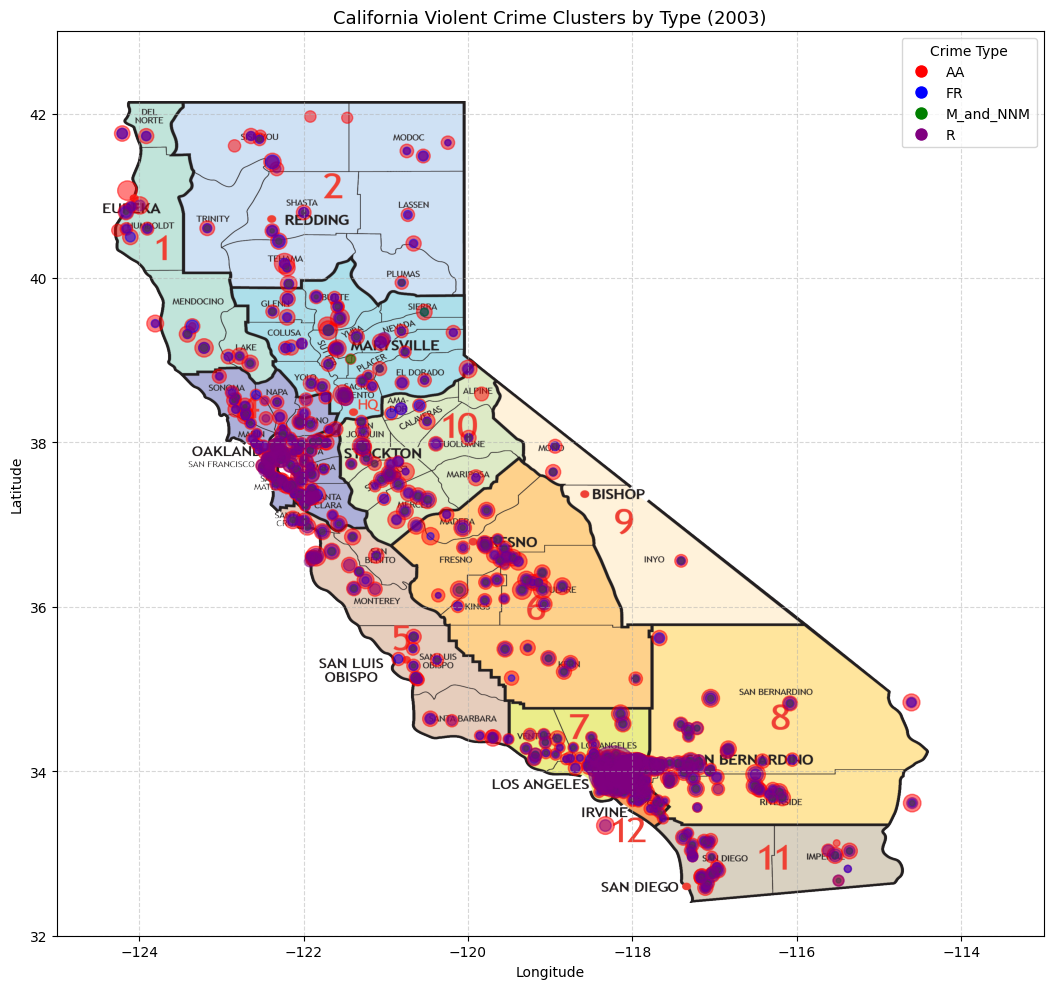

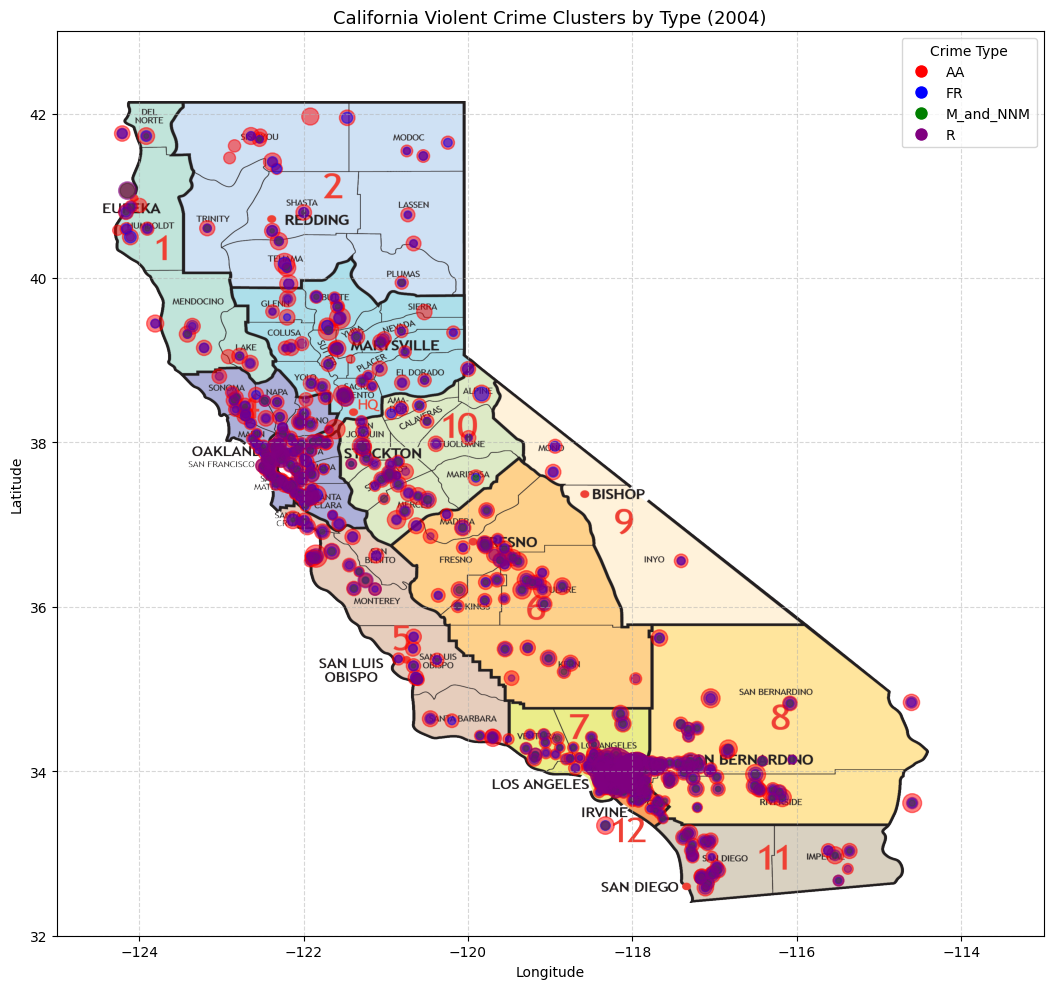

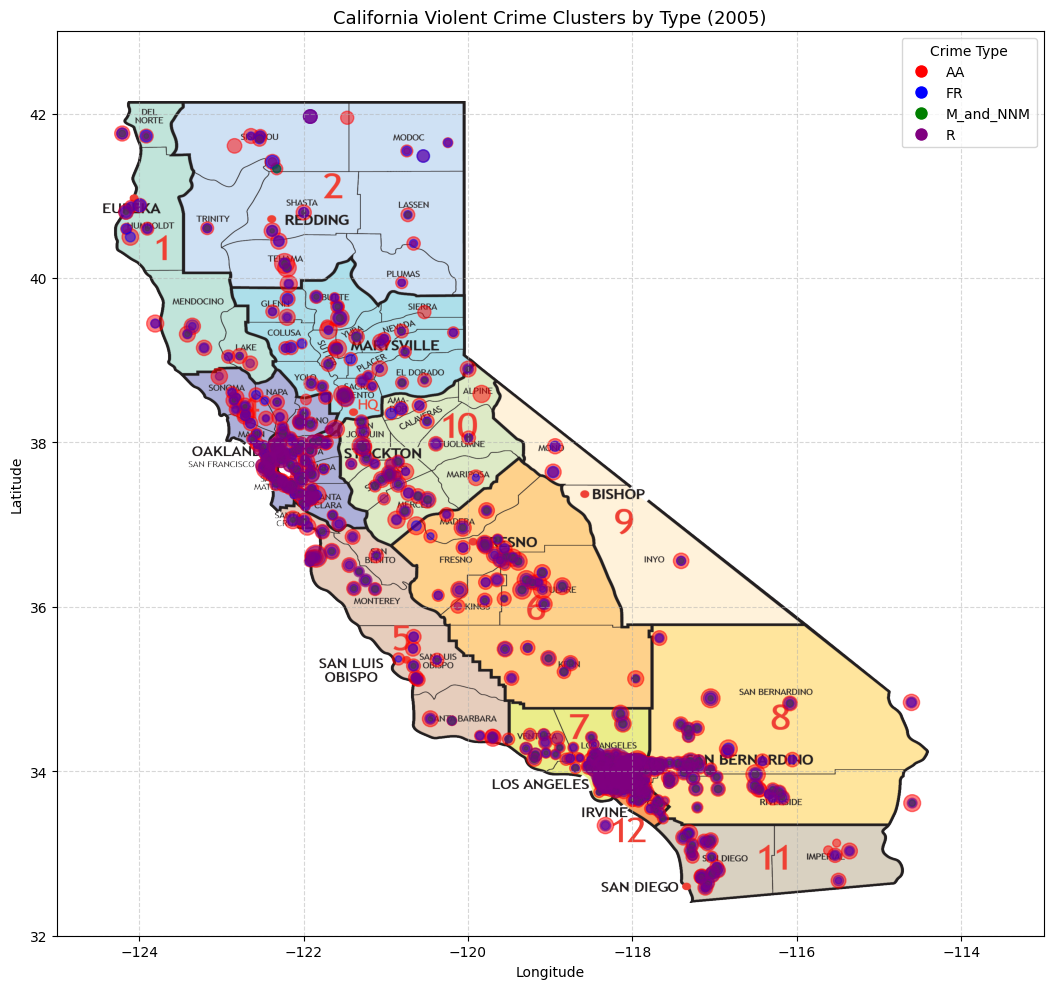

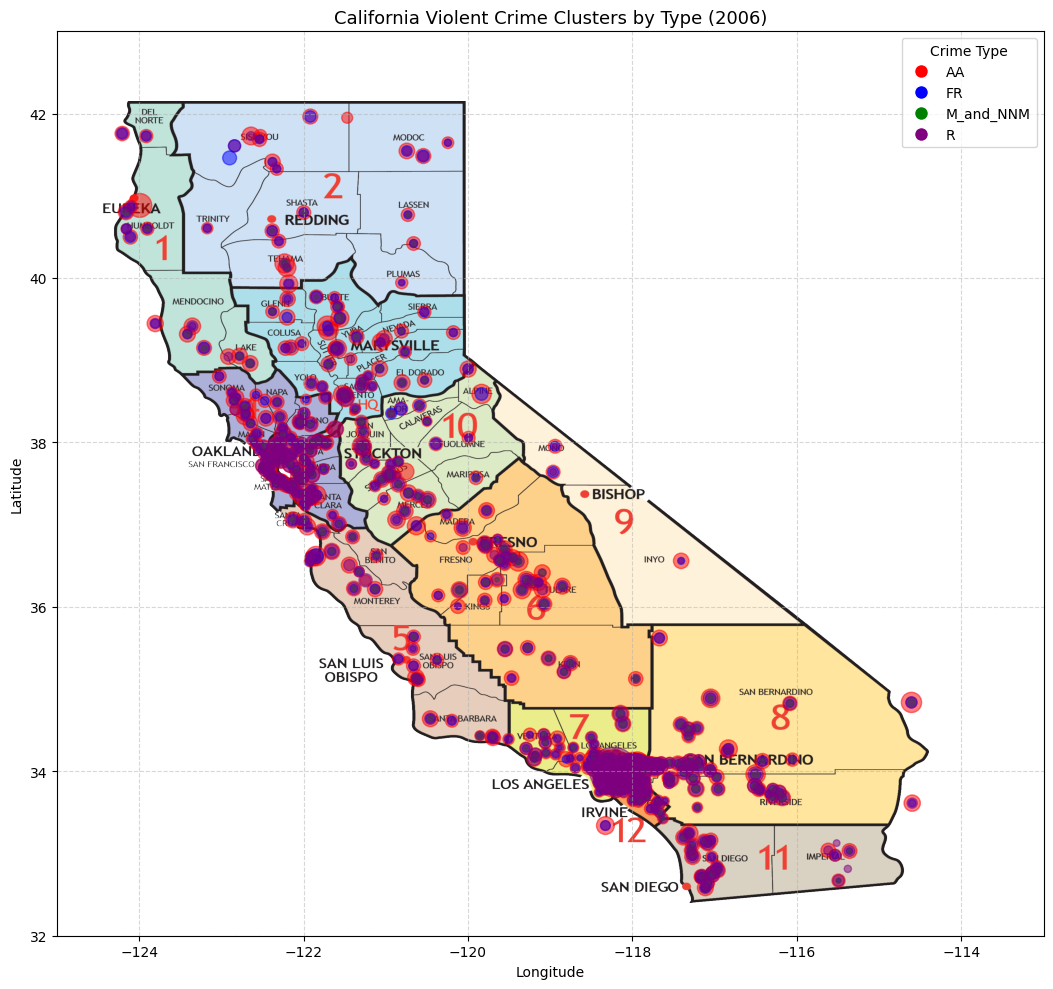

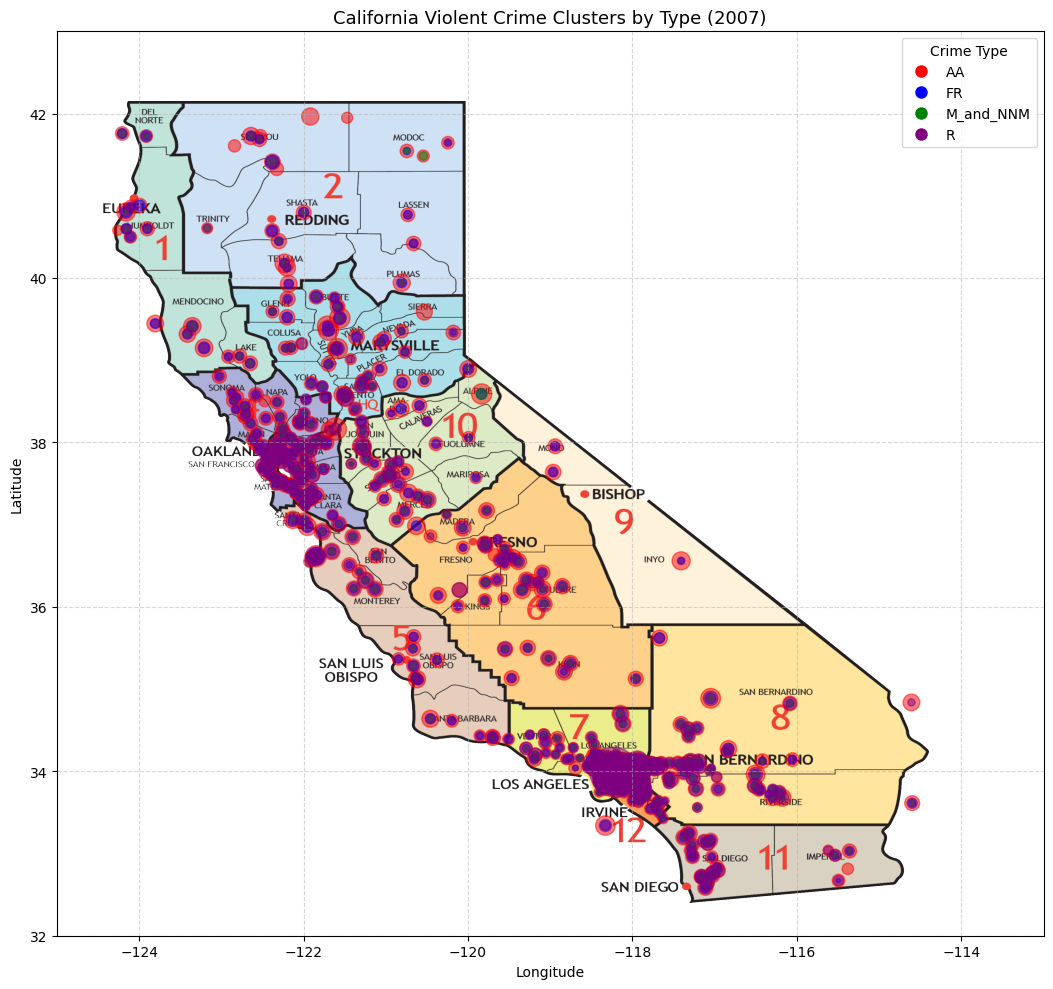

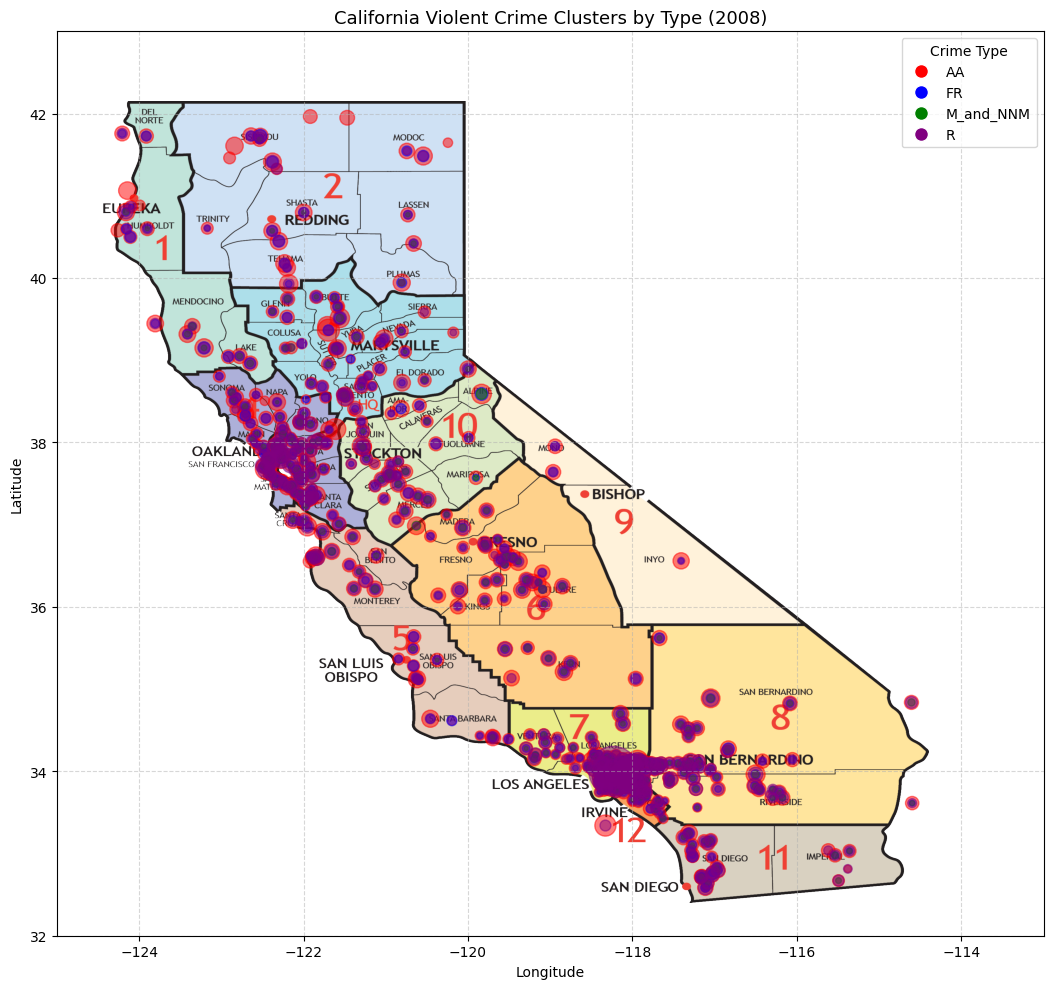

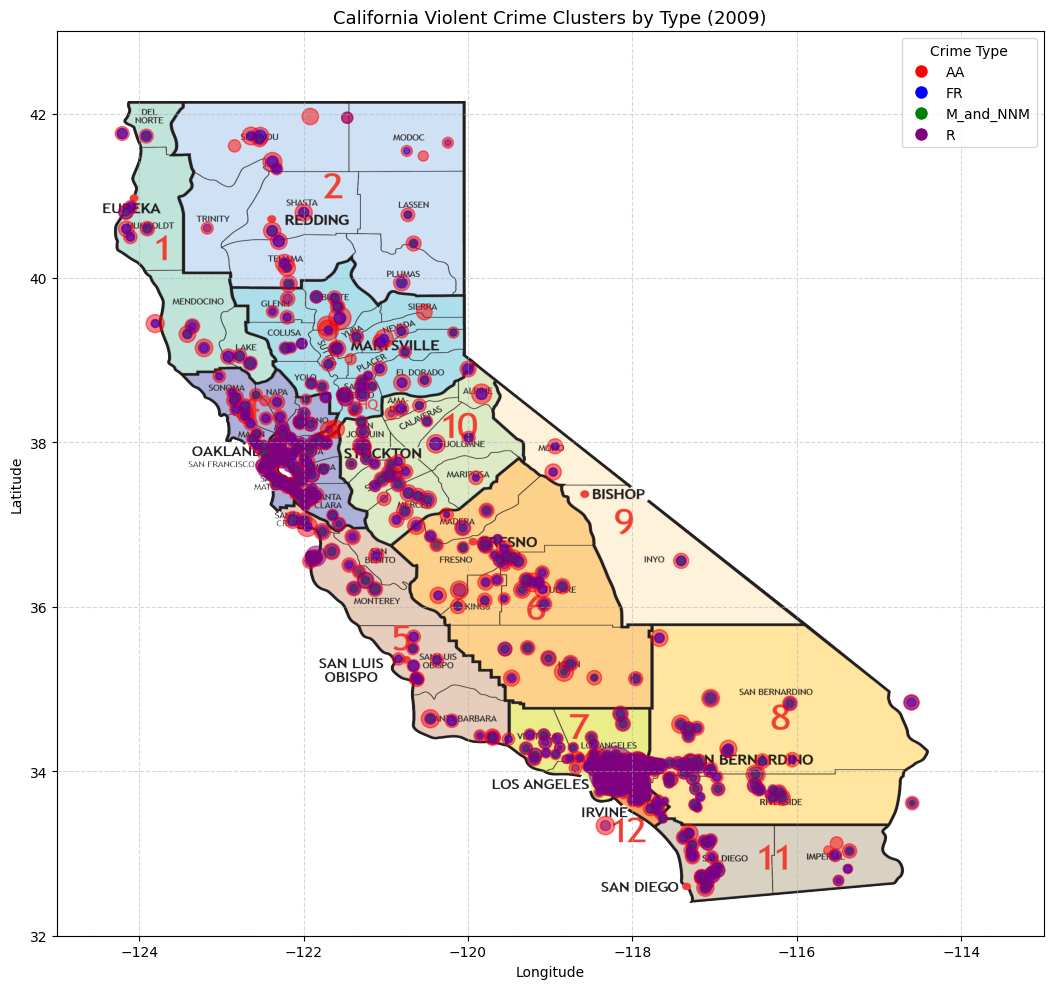

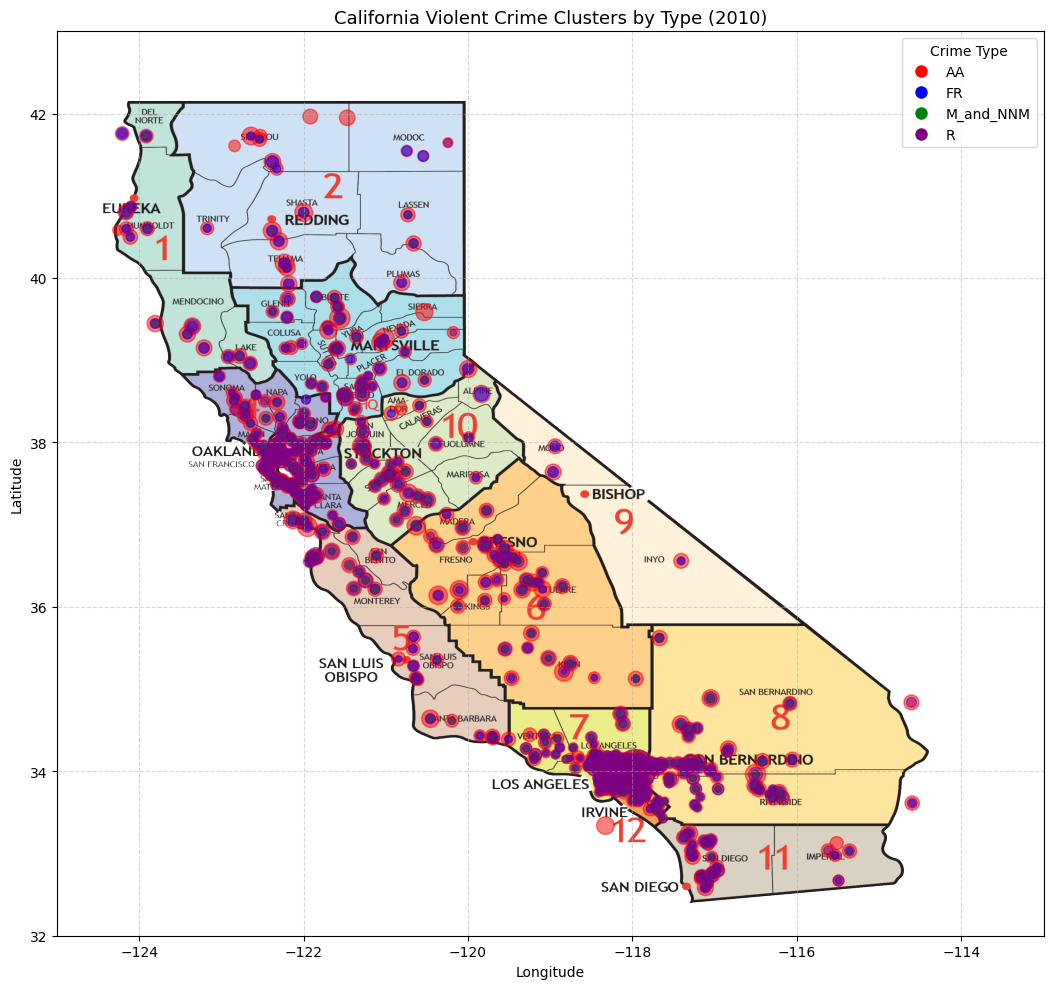

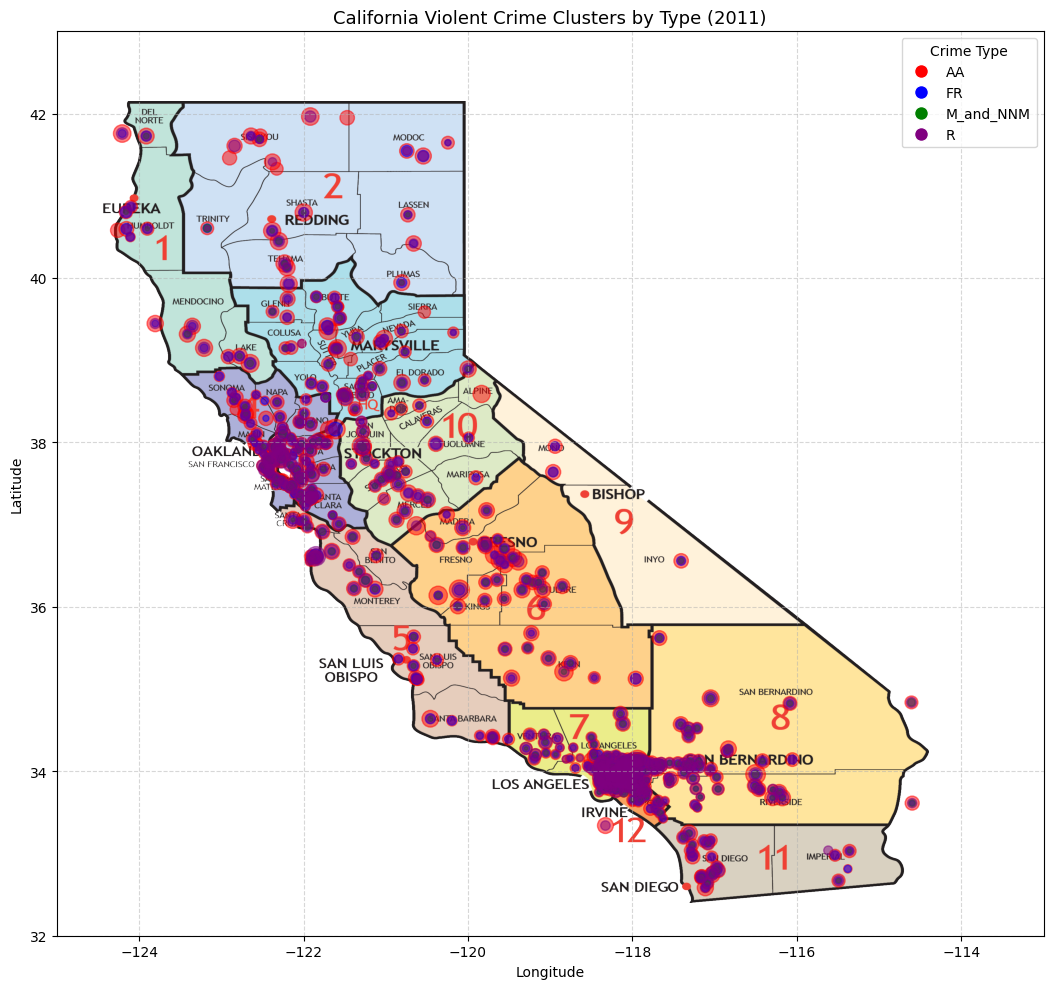

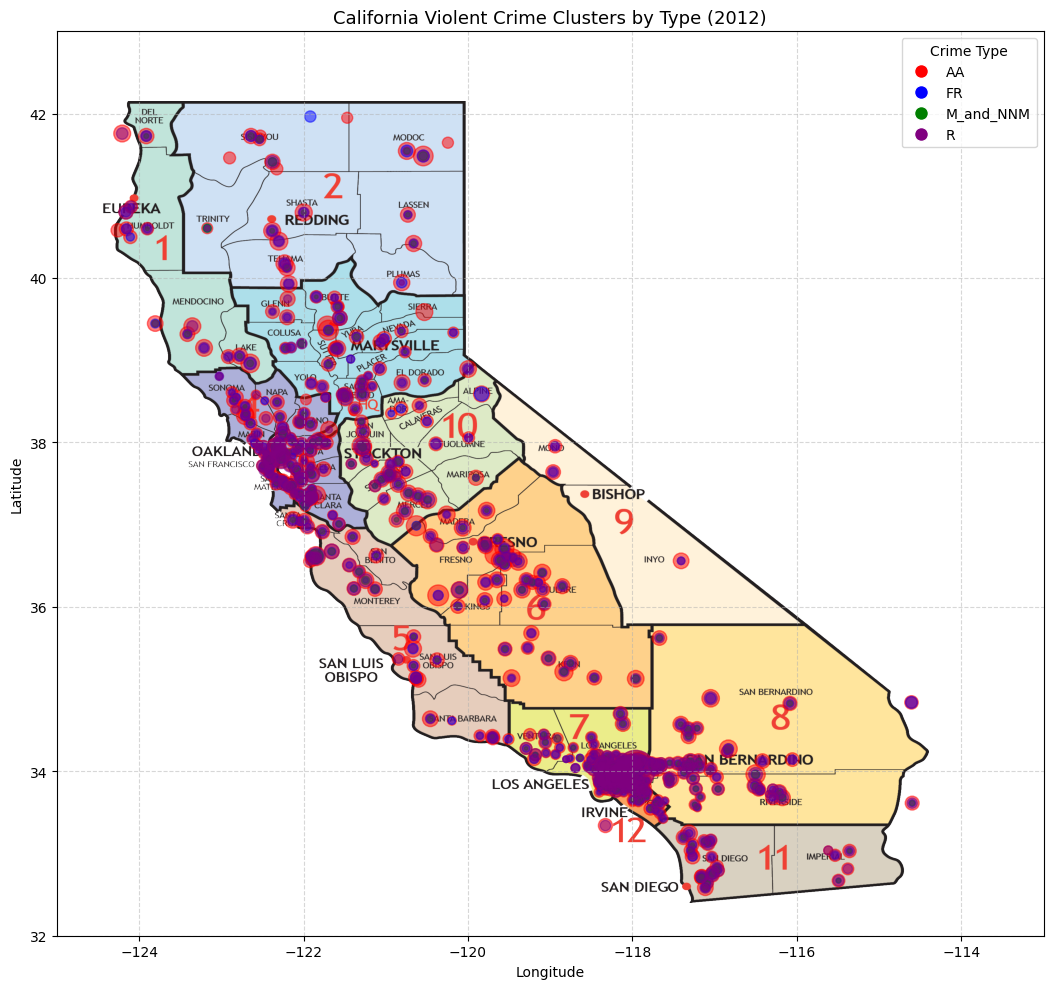

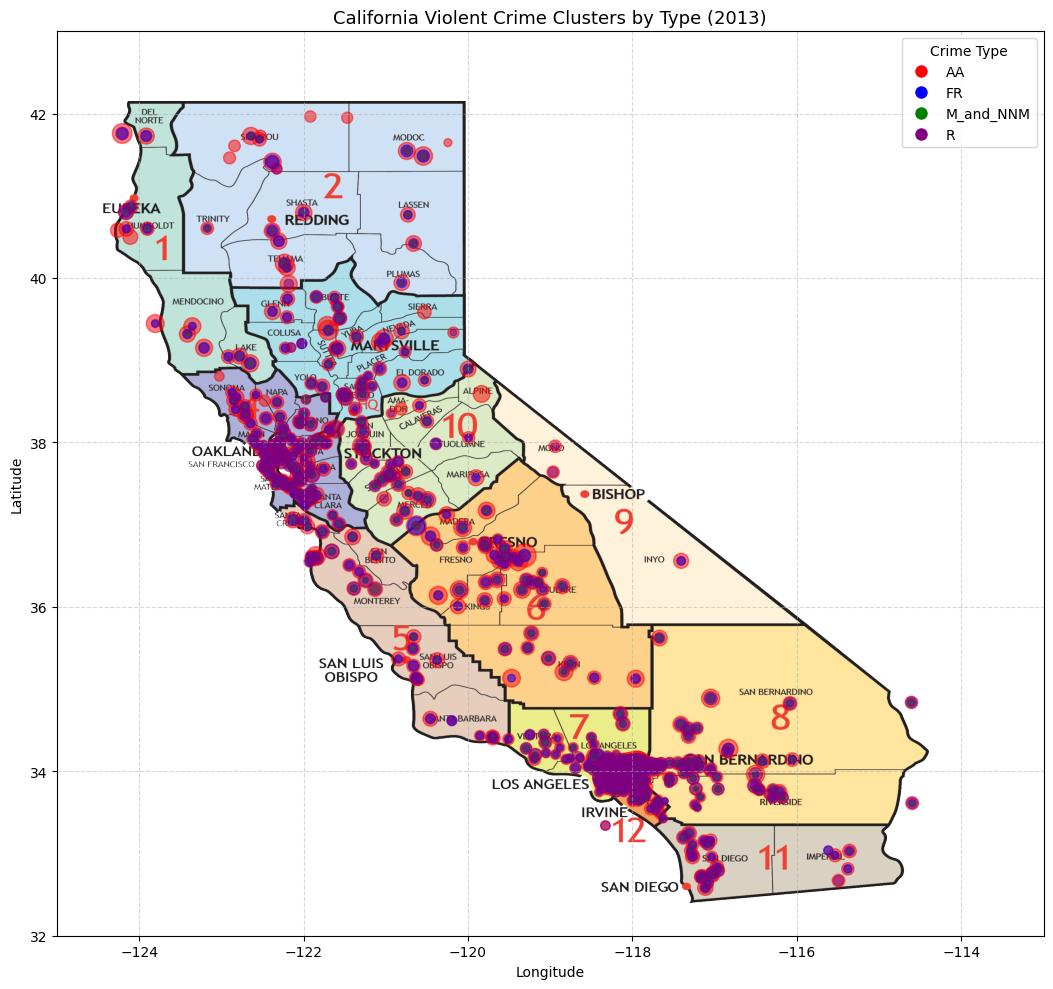

<Figure size 640x480 with 0 Axes>

In [ ]:
for year in range(2000, 2014):
    plot_crime_clusters(year)

plt.tight_layout()
plt.show()

## 3. GDP
Our database was missing something essential: the GDP. Initially, we tried to merge it ourselves, but we encountered several issues and inconsistencies. After multiple attempts, we decided to rely on an AI assistant to guide us through the process and help us generate the final, clean dataset.

In [26]:
df=pd.read_csv("VCC_with_GDP.csv")

## 4. Exploratory Data Analysis (EDA) for Machine Learning

In this section, we will analyze the data to prepare it for machine learning tasks including:
- **K-Means Clustering**: To detect natural groups of regions or crime patterns.
- **K-Nearest Neighbors (KNN)**: To predict labels based on proximity in feature space.
- **Principal Component Analysis (PCA)**: To reduce dimensionality and identify the most informative features.

We will explore feature distributions, potential cluster structures, class separability, and dimensionality.

In [27]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [28]:
print(df.info())
print(df.describe())

# Null values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7127 entries, 0 to 7126
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reportyear      7127 non-null   int64  
 1   geoname         7127 non-null   object 
 2   geotypevalue    7127 non-null   int64  
 3   county_name     7127 non-null   object 
 4   county_fips     7127 non-null   int64  
 5   region_name     7127 non-null   object 
 6   region_code     7127 non-null   int64  
 7   dof_population  7127 non-null   int64  
 8   AA              7127 non-null   float64
 9   FR              7127 non-null   float64
 10  M_and_NNM       7127 non-null   float64
 11  R               7127 non-null   float64
 12  VCT             7127 non-null   float64
 13  rate            7127 non-null   float64
 14  lat             7127 non-null   float64
 15  lon             7127 non-null   float64
 16  gdp_dollars     6623 non-null   float64
dtypes: float64(9), int64(5), object(3

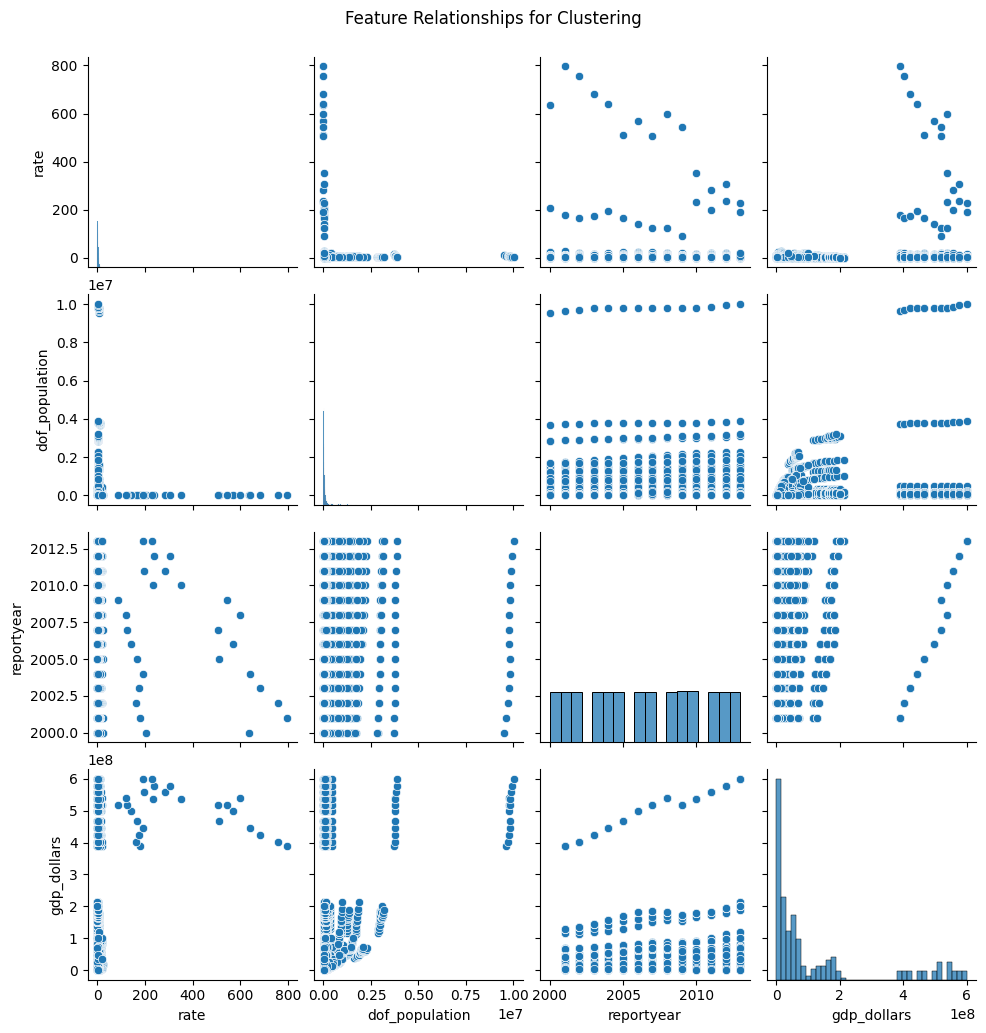

In [43]:
# Pairplot of selected numerical features
features_for_clustering = ['rate', 'dof_population', 'reportyear', 'gdp_dollars']

sns.pairplot(df[features_for_clustering])
plt.suptitle("Feature Relationships for Clustering", y=1.03)
plt.show()

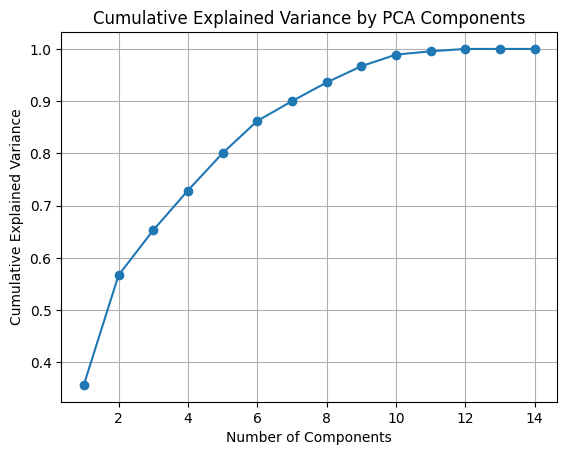

[0.35703566 0.56679548 0.65296891 0.72900888 0.80049263 0.86210969
 0.90001329 0.93585319 0.96687796 0.98909939 0.99538498 0.99999999
 1.         1.        ]


In [35]:
numeric_cols = df.select_dtypes(include='number').columns
# Use all numeric features for PCA
X = df[numeric_cols].dropna()  # Drop rows with missing values (or fill)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()
print(pca.explained_variance_ratio_.cumsum())

### Observations from EDA

- The numeric features such as `violent_crimes`, `dof_population`, and `unemployment_rate` show moderate correlation and some potential for clustering. Counties with high population often have higher total violent crime counts, but normalizing by population reveals more nuanced patterns.
  
- The PCA output enlights us the following:

    - The first component explains 38.06% of the variance in the data.

    - The second component, when added, explains a cumulative 57.87% of the variance.

    - By the 11th component, nearly 100% of the variance is explained, and after the 12th component, the cumulative variance stops increasing, remaining at 1, indicating that all the variance is captured.

- This suggests that the data can be effectively reduced to a smaller number of components without losing much information. For example, the first 5 components could be retained to explain around 82.26% of the variance.

## 5. K-Nearest Neighbours

In order to use rate as our target, we aim to split said columns into three groups. The three chosen categories for our classification target will be low (0), medium (1) and large (2).

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [37]:
df = df.dropna(subset=["rate"])
df["rate_categorization"] = pd.qcut(df["rate"], q=3, labels=[0, 1, 2])

k = 1 → Accuracy = 0.40
k = 3 → Accuracy = 0.43
k = 5 → Accuracy = 0.44
k = 7 → Accuracy = 0.45
k = 10 → Accuracy = 0.46


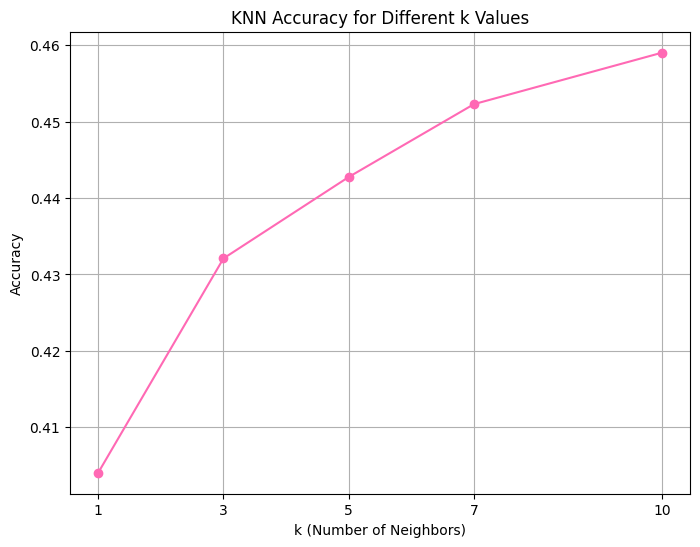

In [38]:
features = ["county_fips", "gdp_dollars"]
X = df[features]
y = df["rate_categorization"]
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
k_test_values = [1, 3, 5, 7, 10]
accuracies = []
for k in k_test_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    accuracies.append(score)
    print(f"k = {k} → Accuracy = {score:.2f}")
plt.figure(figsize=(8, 6))
plt.plot(k_test_values, accuracies, marker='o', color='hotpink')
plt.title("KNN Accuracy for Different k Values")
plt.xlabel("k (Number of Neighbors)")
plt.xticks(k_test_values)
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

k = 1 → Accuracy = 0.95
k = 3 → Accuracy = 0.96
k = 5 → Accuracy = 0.96
k = 7 → Accuracy = 0.96
k = 10 → Accuracy = 0.95


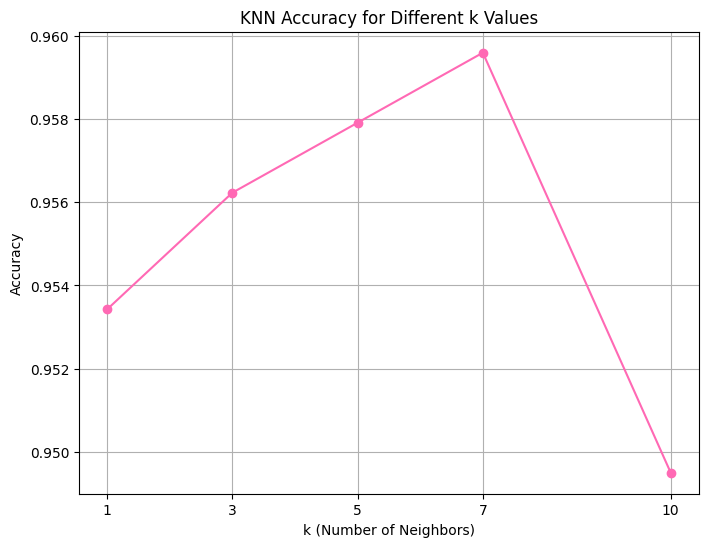

In [39]:
features = ["AA", "FR", "M_and_NNM", "R", "VCT"]
X = df[features]
y = df["rate_categorization"]
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
k_test_values = [1, 3, 5, 7, 10]
accuracies = []
for k in k_test_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    accuracies.append(score)
    print(f"k = {k} → Accuracy = {score:.2f}")
plt.figure(figsize=(8, 6))
plt.plot(k_test_values, accuracies, marker='o', color='hotpink')
plt.title("KNN Accuracy for Different k Values")
plt.xlabel("k (Number of Neighbors)")
plt.xticks(k_test_values)
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()  

We make sure that for our KNN the best method was using the median. 

In [40]:
mean_gdp = df["gdp_dollars"].mean()
median_gdp = df["gdp_dollars"].median()
difference= mean_gdp - median_gdp
print(f"Mean GDP: {mean_gdp:.2f}")
print(f"Median GDP: {median_gdp:.2f}")
print(f"Difference between the Mean GDP and Median GDP: {difference:.2f}")

Mean GDP: 128489749.12
Median GDP: 46573826.00
Difference between the Mean GDP and Median GDP: 81915923.12


By comparing both the median and mean results, we see that there is a big difference between the values. We are assuring the best choice was applying the median.

## 6. Recommender System